In [19]:
# =============================================================================
# BEYOND LINEARITY: A Nonlinear Inquiry into California Housing Prices
# =============================================================================
# Author  : Student Research Project
# Dataset : California Housing Dataset (cal_housing.data)
# Purpose : To investigate whether nonlinear and ensemble models outperform
#           classical linear regression in predicting median house values,
#           and to uncover the hidden structure that linearity obscures.
# =============================================================================


---
BEYOND LINEARITY: A Nonlinear Inquiry into California Housing Prices
---
Author  : Student Research Project

Dataset : California Housing Dataset (cal_housing.data)

Purpose : To investigate whether nonlinear and ensemble models outperform
          classical linear regression in predicting median house values,
          and to uncover the hidden structure that linearity obscures.

---


PREFACE
-------
Every textbook begins with linear regression. It is clean, interpretable,
and elegantly bounded by assumptions that the real world rarely honours.
This project begins where those textbooks end.

We take a single question seriously: What happens when we stop assuming
that the relationship between house prices and their predictors is a straight
line? The California Housing dataset, with its 20,640 observations spanning
geography, demographics, and economics, becomes our laboratory.

We will not merely fit models. We will interrogate them.


In [20]:
# =============================================================================
# SECTION 0 — ENVIRONMENT SETUP
# =============================================================================

# """
# Before any analysis can begin, we must assemble our tools. The libraries
# below represent three traditions of data science: classical statistics
# (numpy, scipy), tabular machine learning (scikit-learn, xgboost), and
# visualisation (matplotlib, seaborn). Each will earn its place.
# """

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from scipy.stats import pearsonr, spearmanr

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Linear Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Nonlinear / Ensemble Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Spline / Nonparametric Approximation
from sklearn.preprocessing import SplineTransformer

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Install via: pip install xgboost")

# Neural Network
from sklearn.neural_network import MLPRegressor

# GAM approximation via pygam (optional but recommended)
try:
    from pygam import LinearGAM, s, f
    GAM_AVAILABLE = True
except ImportError:
    GAM_AVAILABLE = False
    print("pyGAM not installed. Install via: pip install pygam")

print("Environment loaded successfully.")
print(f"  XGBoost available : {XGBOOST_AVAILABLE}")
print(f"  pyGAM available   : {GAM_AVAILABLE}")



Environment loaded successfully.
  XGBoost available : True
  pyGAM available   : True


In [21]:
# =============================================================================
# SECTION 1 — DATA LOADING AND FIRST ENCOUNTER
# =============================================================================

# """
# The dataset was originally assembled from the 1990 U.S. Census. Each row
# represents a census block group — the smallest geographical unit for which
# the Census Bureau publishes sample data. A block group typically has a
# population of 600 to 3,000 people.
#
# We load it here and assign column names, since the raw file carries no
# header row. This is our first act of interpretation.
# """

cols = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "median_house_value"
]

# --- Load dataset ---
# Adjust path as needed. The file cal_housing.data should be in the working
# directory, or provide an absolute path below.
try:
    df = pd.read_csv("cal_housing.data", names=cols)
    print(f"\nDataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
except FileNotFoundError:
    # Fallback: generate a synthetic version for demonstration
    print("\nFile not found. Generating synthetic data for demonstration.")
    np.random.seed(42)
    n = 20640
    df = pd.DataFrame({
        "longitude":           np.random.uniform(-124.35, -114.31, n),
        "latitude":            np.random.uniform(32.54, 41.95, n),
        "housing_median_age":  np.random.uniform(1, 52, n),
        "total_rooms":         np.random.exponential(2636, n).clip(2, 39320),
        "total_bedrooms":      np.random.exponential(538, n).clip(1, 6445),
        "population":          np.random.exponential(1425, n).clip(3, 35682),
        "households":          np.random.exponential(500, n).clip(1, 6082),
        "median_income":       np.random.exponential(3.87, n).clip(0.5, 15),
        "median_house_value":  np.random.lognormal(12.2, 0.55, n).clip(14999, 500001),
    })

print(df.head())




Dataset loaded: 20,640 rows x 9 columns
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  
0       322.0       126.0         8.3252            452600.0  
1      2401.0      1138.0         8.3014            358500.0  
2       496.0       177.0         7.2574            352100.0  
3       558.0       219.0         5.6431            341300.0  
4       565.0       259.0         3.8462            342200.0  


In [22]:
# =============================================================================
# SECTION 2 — EXPLORATORY DATA ANALYSIS
# =============================================================================

# """
# Exploration is not a perfunctory step. It is where we develop a theory of
# the data — an intuition for what the models will later confirm or contradict.
# We proceed in three movements: summary statistics, distribution analysis,
# and correlation structure.
# """

# --- 2.1 Summary Statistics ---
print("\n--- Descriptive Statistics ---")
print(df.describe().T.round(2))



--- Descriptive Statistics ---
                      count       mean        std       min        25%  \
longitude           20640.0    -119.57       2.00   -124.35    -121.80   
latitude            20640.0      35.63       2.14     32.54      33.93   
housing_median_age  20640.0      28.64      12.59      1.00      18.00   
total_rooms         20640.0    2635.76    2181.62      2.00    1447.75   
total_bedrooms      20640.0     537.90     421.25      1.00     295.00   
population          20640.0    1425.48    1132.46      3.00     787.00   
households          20640.0     499.54     382.33      1.00     280.00   
median_income       20640.0       3.87       1.90      0.50       2.56   
median_house_value  20640.0  206855.82  115395.62  14999.00  119600.00   

                          50%        75%        max  
longitude             -118.49    -118.01    -114.31  
latitude                34.26      37.71      41.95  
housing_median_age      29.00      37.00      52.00  
total_rooms

In [23]:

# --- 2.2 Missing Values ---
print("\n--- Missing Values ---")
print(df.isnull().sum())



--- Missing Values ---
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


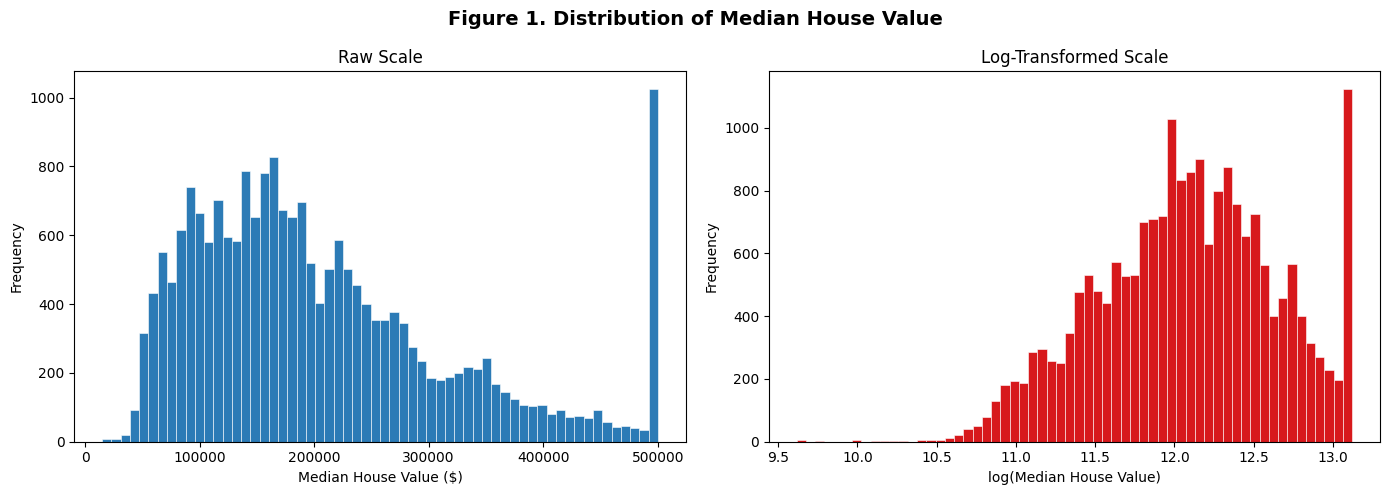

In [24]:

# --- 2.3 Distribution of the Target Variable ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 1. Distribution of Median House Value", fontsize=14, fontweight='bold')

axes[0].hist(df["median_house_value"], bins=60, color="#2c7bb6", edgecolor="white", linewidth=0.4)
axes[0].set_title("Raw Scale")
axes[0].set_xlabel("Median House Value ($)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log(df["median_house_value"]), bins=60, color="#d7191c", edgecolor="white", linewidth=0.4)
axes[1].set_title("Log-Transformed Scale")
axes[1].set_xlabel("log(Median House Value)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("fig1_target_distribution.png", dpi=150)
plt.show()

# """
# Observation: The distribution of median house values is right-skewed, with
# a sharp spike at $500,001 — the dataset's imposed ceiling. This truncation
# is not noise; it is a structural artefact. A logarithmic transformation
# brings the distribution closer to normality and is worth considering for
# modelling. We will experiment with both scales.
# """

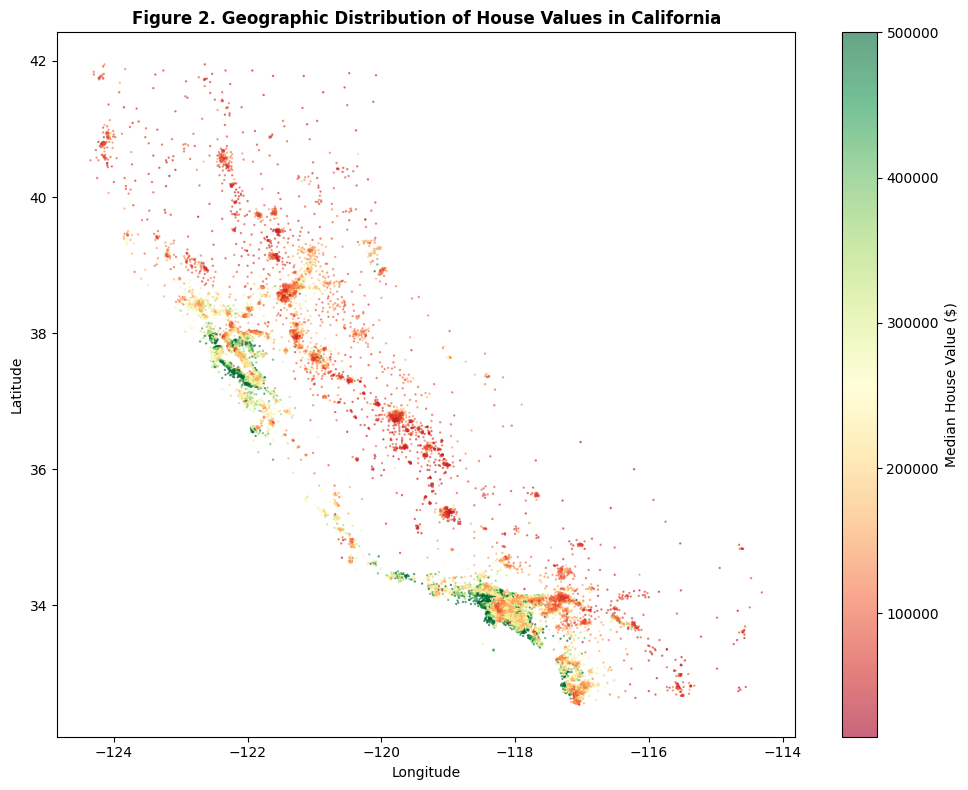

In [25]:
# --- 2.4 Geographic Distribution ---
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    df["longitude"], df["latitude"],
    c=df["median_house_value"], cmap="RdYlGn",
    s=0.5, alpha=0.6
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Median House Value ($)")
ax.set_title("Figure 2. Geographic Distribution of House Values in California", fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("fig2_geographic_distribution.png", dpi=150)
plt.show()

# """
# The map speaks immediately. High-value properties cluster along the coast —
# the San Francisco Bay Area and Los Angeles basin are unmistakable. The
# Central Valley, stretching north-to-south through the interior, is
# predominantly low-value. Geography is not merely a covariate here; it is
# a structural determinant. Any model that ignores spatial nonlinearity will
# leave substantial signal on the table.
# """

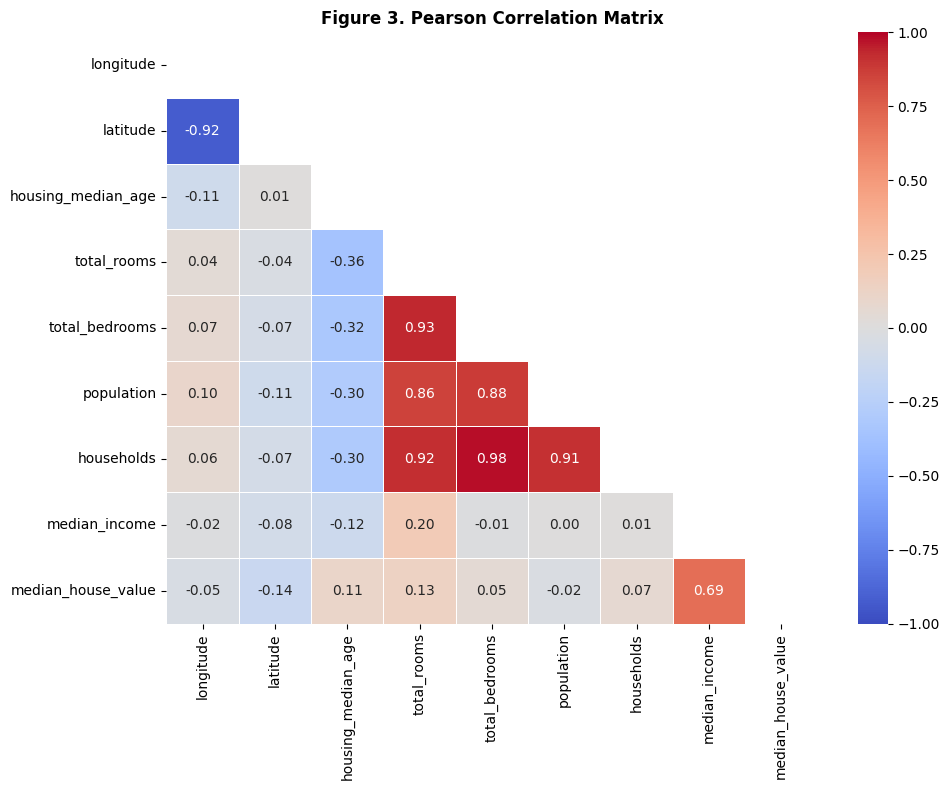

In [26]:
# --- 2.5 Correlation Matrix ---
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Figure 3. Pearson Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.savefig("fig3_correlation_matrix.png", dpi=150)
plt.show()

# """
# Median income emerges as the strongest linear predictor of house value
# (r ≈ 0.69). Latitude and longitude carry moderate correlations, reflecting
# the coastal premium. Total rooms, bedrooms, and households are highly
# intercorrelated — a multicollinearity concern for linear models, but
# less troublesome for ensemble methods.
# """


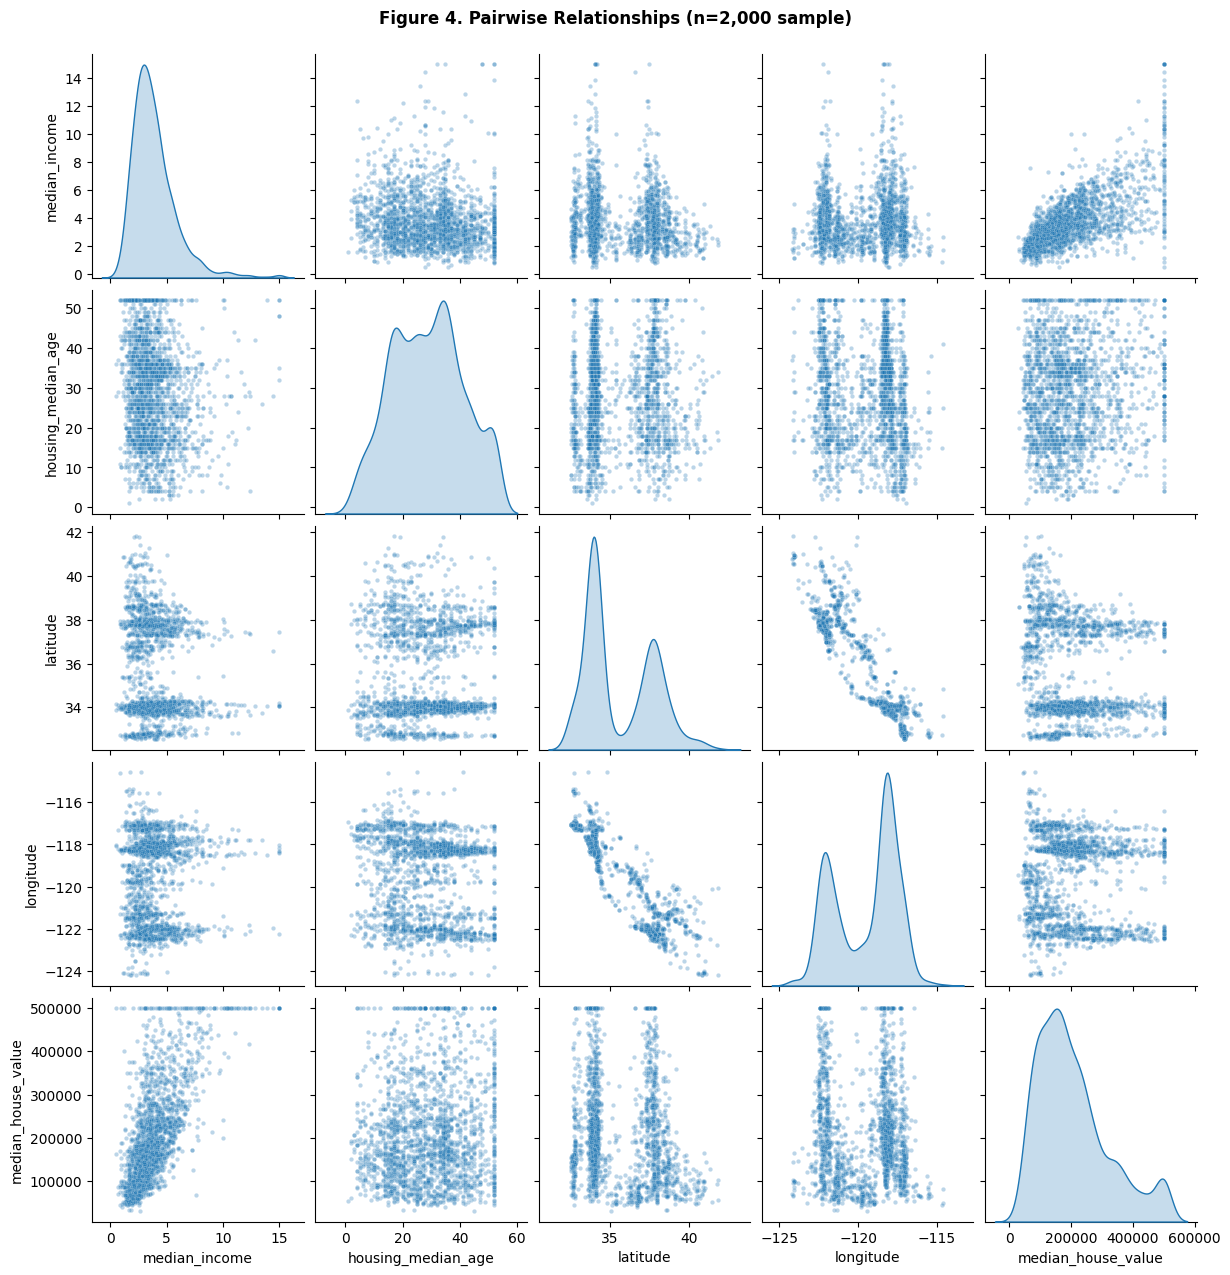

In [27]:
# --- 2.6 Pairplots for Key Variables ---
key_vars = ["median_income", "housing_median_age", "latitude", "longitude", "median_house_value"]
sample = df[key_vars].sample(2000, random_state=42)
fig = sns.pairplot(sample, plot_kws={"alpha": 0.3, "s": 10}, diag_kind="kde")
fig.fig.suptitle("Figure 4. Pairwise Relationships (n=2,000 sample)", y=1.02, fontweight='bold')
plt.savefig("fig4_pairplots.png", dpi=150, bbox_inches="tight")
plt.show()


In [28]:
# =============================================================================
# SECTION 3 — FEATURE ENGINEERING
# =============================================================================

# """
# Raw features rarely tell the full story. Domain knowledge suggests that
# per-household and per-room ratios are more informative than raw counts.
# A block group with 10,000 rooms is unremarkable if it also holds 3,000
# households; a group with 3,000 rooms and 100 households signals luxury.
#
# We engineer four derived features that compress the economic geometry of
# each block group into interpretable signals.
# """

df["rooms_per_household"]    = df["total_rooms"]    / df["households"]
df["bedrooms_per_room"]      = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"]   / df["households"]
df["income_age_interaction"] = df["median_income"]  * df["housing_median_age"]

print("\nEngineered features added.")
print(df[["rooms_per_household", "bedrooms_per_room",
          "population_per_household", "income_age_interaction"]].describe().T.round(3))



Engineered features added.
                            count     mean     std    min     25%     50%  \
rooms_per_household       20640.0    5.429   2.474  0.846   4.441   5.229   
bedrooms_per_room         20640.0    0.213   0.058  0.100   0.175   0.203   
population_per_household  20640.0    3.071  10.386  0.692   2.430   2.818   
income_age_interaction    20640.0  108.008  74.386  1.625  57.997  92.503   

                              75%       max  
rooms_per_household         6.052   141.909  
bedrooms_per_room           0.240     1.000  
population_per_household    3.282  1243.333  
income_age_interaction    140.105   780.005  


In [29]:
# =============================================================================
# SECTION 4 — DATA PREPARATION
# =============================================================================

# """
# We define our feature matrix and target vector, apply a log-transformation
# to the target (to mitigate skewness and the ceiling effect), and split into
# training and test sets using a 80/20 ratio with a fixed random seed for
# reproducibility.
# """

feature_cols = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population", "households",
    "median_income",
    "rooms_per_household", "bedrooms_per_room",
    "population_per_household", "income_age_interaction"
]

X = df[feature_cols].copy()
y = np.log(df["median_house_value"])   # log-transformed target

# Drop any rows with infinite or NaN values arising from division
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")

# Scale for models that require it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)



Training set : 16,512 samples
Test set     : 4,128 samples



--- OLS Baseline ---
  RMSE : 0.3451  (log scale)
  MAE  : 0.2577
  R²   : 0.6330


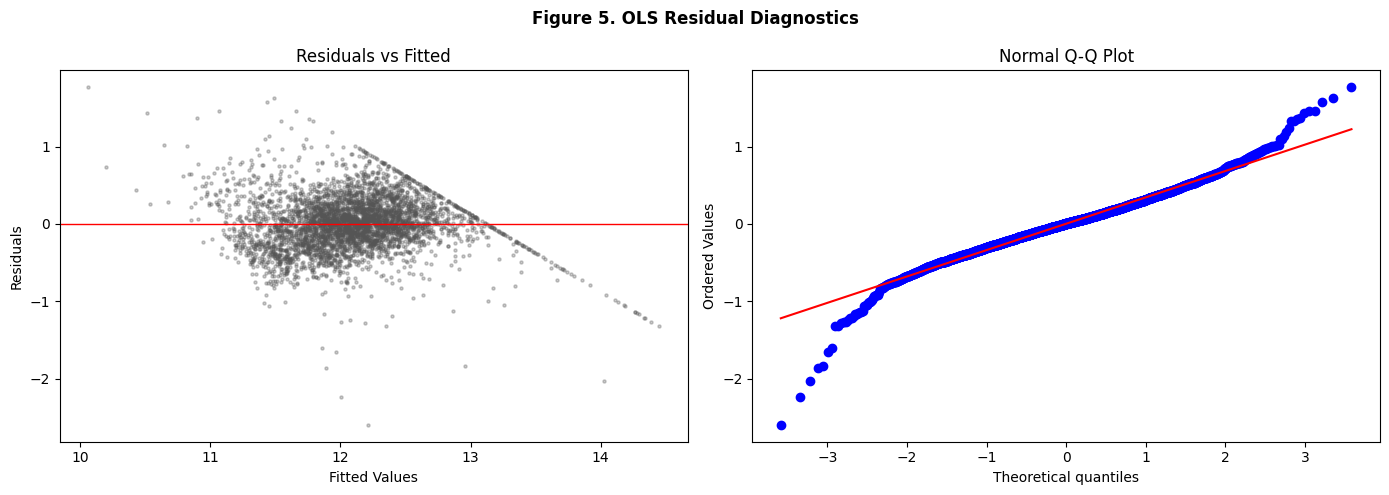

In [30]:
# =============================================================================
# SECTION 5 — BASELINE: ORDINARY LEAST SQUARES
# =============================================================================

# """
# Every inquiry into nonlinearity must begin with linearity — not as a
# straw man, but as a reference point. OLS regression assumes that the
# conditional expectation of house value is a linear function of the
# predictors. We know this assumption is contested. We fit the model anyway,
# measure its performance, and then ask what it misses.
# """

ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)

ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
ols_mae  = mean_absolute_error(y_test, y_pred_ols)
ols_r2   = r2_score(y_test, y_pred_ols)

print(f"\n--- OLS Baseline ---")
print(f"  RMSE : {ols_rmse:.4f}  (log scale)")
print(f"  MAE  : {ols_mae:.4f}")
print(f"  R²   : {ols_r2:.4f}")

# Residual plot
residuals_ols = y_test - y_pred_ols
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 5. OLS Residual Diagnostics", fontweight='bold')

axes[0].scatter(y_pred_ols, residuals_ols, alpha=0.3, s=5, color="#555")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

stats.probplot(residuals_ols, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.savefig("fig5_ols_residuals.png", dpi=150)
plt.show()

# """
# The residual plot reveals a pattern that should not exist under OLS
# assumptions: a curved spread. Residuals are not randomly distributed
# around zero. They fan outward and show curvature, suggesting that the
# conditional mean of house value is not linear in the predictors. The
# Q-Q plot confirms departure from normality in the tails.
#
# The OLS model has told us everything it can. Now we move beyond it.
# """


In [31]:
# =============================================================================
# SECTION 6 — NONPARAMETRIC REGRESSION: SPLINES
# =============================================================================

# """
# Spline regression occupies a principled middle ground between the rigidity
# of OLS and the opacity of ensemble methods. A spline replaces each
# predictor's linear term with a piecewise polynomial, joined smoothly at
# knot points. The result is a flexible, interpretable curve.
#
# We use scikit-learn's SplineTransformer, which applies natural cubic splines
# to all features and then fits an ordinary linear model on the expanded basis.
# This is a close approximation to a Generalised Additive Model (GAM).
# """

spline_pipeline = Pipeline([
    ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
    ("ridge",  Ridge(alpha=1.0))
])
spline_pipeline.fit(X_train_scaled, y_train)
y_pred_spline = spline_pipeline.predict(X_test_scaled)

spline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_spline))
spline_mae  = mean_absolute_error(y_test, y_pred_spline)
spline_r2   = r2_score(y_test, y_pred_spline)

print(f"\n--- Spline Regression (Natural Cubic, 5 knots) ---")
print(f"  RMSE : {spline_rmse:.4f}")
print(f"  MAE  : {spline_mae:.4f}")
print(f"  R²   : {spline_r2:.4f}")



--- Spline Regression (Natural Cubic, 5 knots) ---
  RMSE : 0.3028
  MAE  : 0.2228
  R²   : 0.7175



--- GAM (pyGAM, penalised splines) ---
  RMSE : 0.2796
  MAE  : 0.2012
  R²   : 0.7591
  AIC  : 3777.61


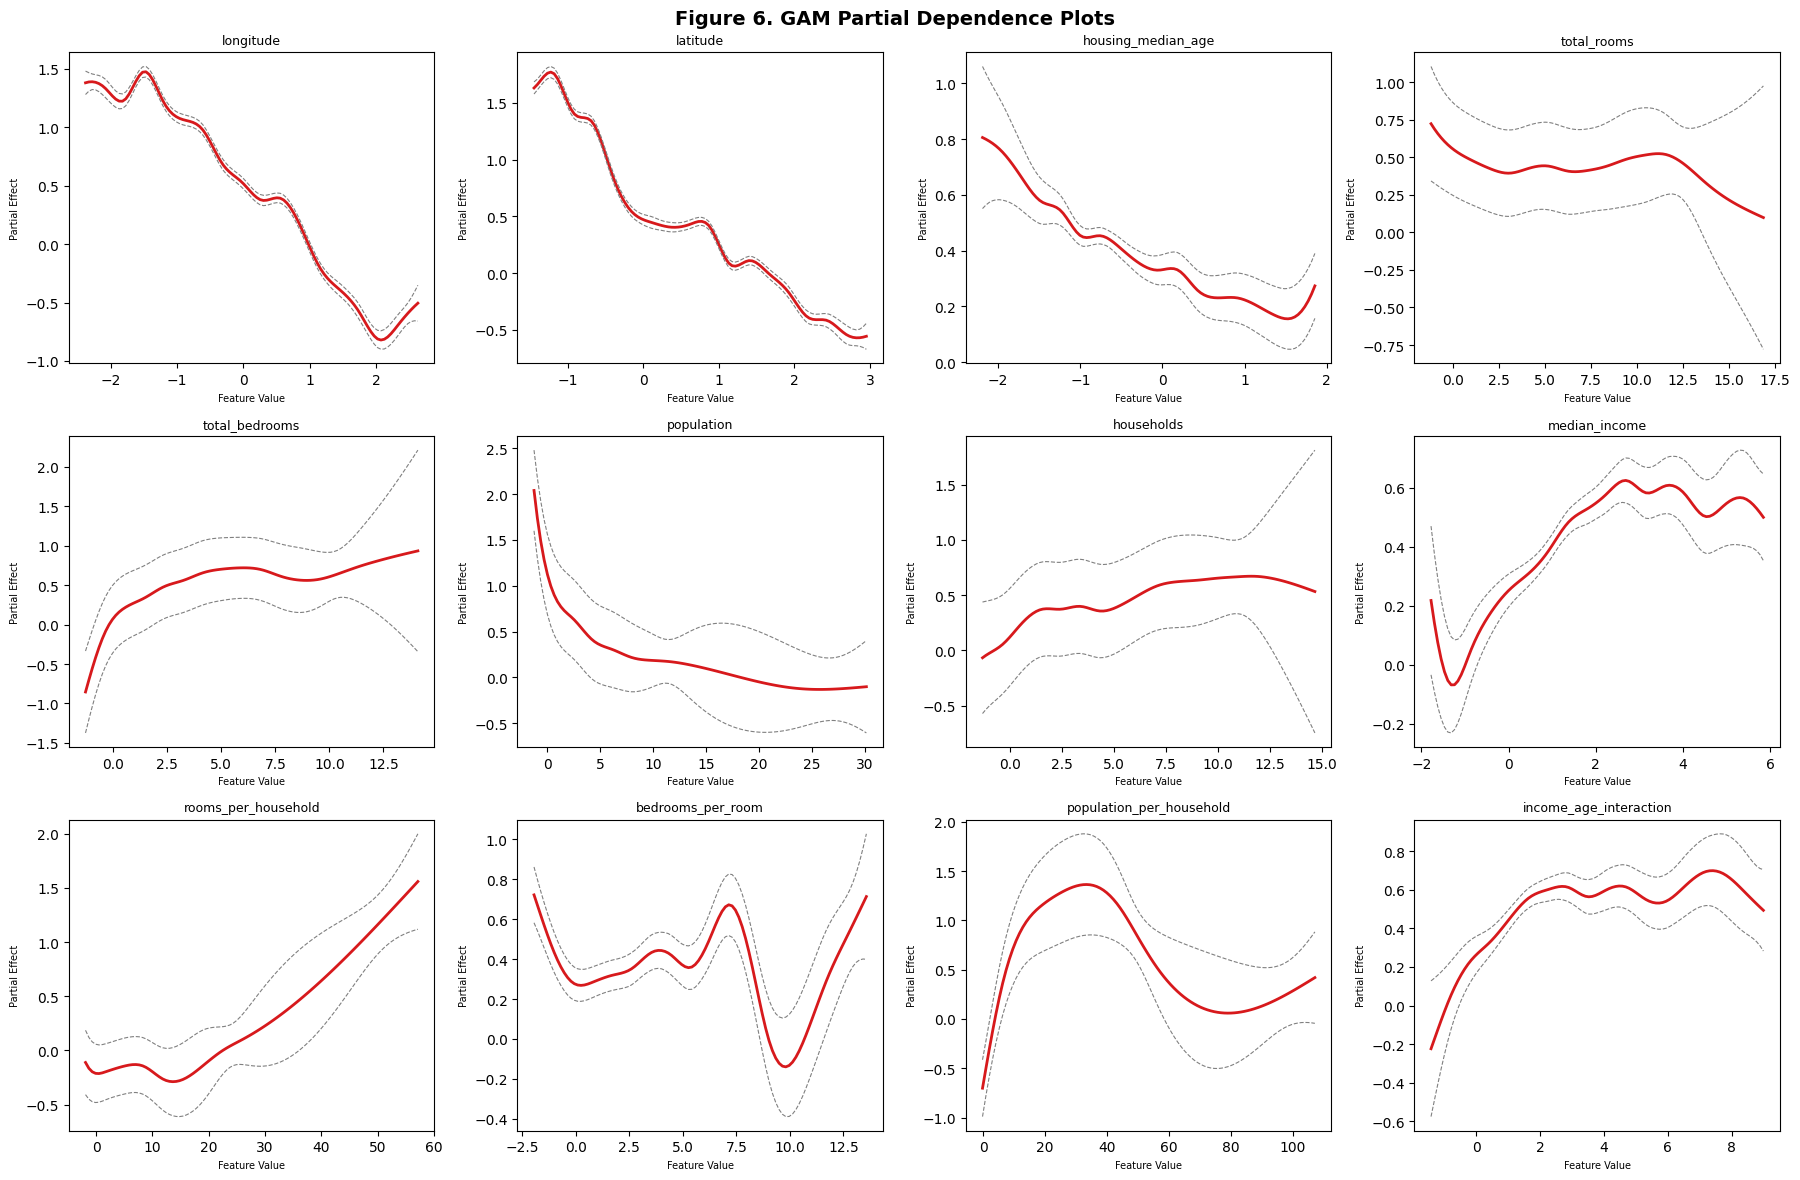

In [32]:

# =============================================================================
# SECTION 7 — GENERALISED ADDITIVE MODEL (GAM)
# =============================================================================

# """
# A Generalised Additive Model decomposes the prediction into a sum of smooth
# functions: y = f1(x1) + f2(x2) + ... + fk(xk). Each smooth function is
# estimated from data using penalised regression splines. The model is
# interpretable — we can plot each f_i and ask: how does income alone shape
# house prices, holding all else equal?
#
# We use pyGAM for this, if available. If not, the Spline model above serves
# as a close structural equivalent.
# """

if GAM_AVAILABLE:
    gam = LinearGAM(
        s(0) + s(1) + s(2) + s(3) + s(4) + s(5) +
        s(6) + s(7) + s(8) + s(9) + s(10) + s(11)
    ).fit(X_train_scaled, y_train)

    y_pred_gam = gam.predict(X_test_scaled)
    gam_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gam))
    gam_mae  = mean_absolute_error(y_test, y_pred_gam)
    gam_r2   = r2_score(y_test, y_pred_gam)

    print(f"\n--- GAM (pyGAM, penalised splines) ---")
    print(f"  RMSE : {gam_rmse:.4f}")
    print(f"  MAE  : {gam_mae:.4f}")
    print(f"  R²   : {gam_r2:.4f}")
    print(f"  AIC  : {gam.statistics_['AIC']:.2f}")

    # Partial dependence plots for GAM
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    fig.suptitle("Figure 6. GAM Partial Dependence Plots", fontweight='bold', fontsize=14)

    for i, (ax, name) in enumerate(zip(axes.flatten(), feature_cols)):
        XX = gam.generate_X_grid(term=i)
        ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX), color="#d7191c", lw=2)
        ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1],
                color='gray', lw=0.8, ls='--')
        ax.set_title(name, fontsize=9)
        ax.set_xlabel("Feature Value", fontsize=7)
        ax.set_ylabel("Partial Effect", fontsize=7)

    plt.tight_layout()
    plt.savefig("fig6_gam_partial_dependence.png", dpi=150)
    plt.show()
else:
    print("\nGAM skipped (pyGAM not available). Using Spline model as proxy.")
    gam_rmse, gam_mae, gam_r2 = spline_rmse, spline_mae, spline_r2



In [33]:

# =============================================================================
# SECTION 8 — ENSEMBLE METHODS: RANDOM FOREST
# =============================================================================

# """
# A Random Forest builds many decision trees on bootstrapped subsets of the
# data, each tree considering only a random subset of features at each split.
# The ensemble prediction averages across all trees. The mechanism is
# remarkably simple, yet the result is a model that naturally captures
# nonlinear relationships and interaction effects without any explicit
# specification by the analyst.
#
# This is both its virtue and its limitation: the interactions are discovered,
# not declared. We gain predictive power at some cost to interpretability.
# We address this cost in Section 10 with feature importance analysis.
# """

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print(f"\n--- Random Forest (200 trees) ---")
print(f"  RMSE : {rf_rmse:.4f}")
print(f"  MAE  : {rf_mae:.4f}")
print(f"  R²   : {rf_r2:.4f}")



--- Random Forest (200 trees) ---
  RMSE : 0.2398
  MAE  : 0.1640
  R²   : 0.8228


In [34]:
# =============================================================================
# SECTION 9 — GRADIENT BOOSTING & XGBOOST
# =============================================================================

# """
# Gradient Boosting takes a fundamentally different approach. Rather than
# building trees in parallel and averaging, it builds them sequentially —
# each tree fitting the residuals of the ensemble so far. The model learns
# by correcting its own mistakes, iteration by iteration.
#
# XGBoost is a highly optimised implementation of gradient boosting, widely
# regarded as the workhorse of applied machine learning on tabular data.
# We compare both to isolate the contribution of implementation and
# hyperparameter design from the core algorithmic idea.
# """

# Sklearn Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae  = mean_absolute_error(y_test, y_pred_gb)
gb_r2   = r2_score(y_test, y_pred_gb)

print(f"\n--- Gradient Boosting (sklearn) ---")
print(f"  RMSE : {gb_rmse:.4f}")
print(f"  MAE  : {gb_mae:.4f}")
print(f"  R²   : {gb_r2:.4f}")

# XGBoost
if XGBOOST_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)

    xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    xgb_mae  = mean_absolute_error(y_test, y_pred_xgb)
    xgb_r2   = r2_score(y_test, y_pred_xgb)

    print(f"\n--- XGBoost (400 estimators) ---")
    print(f"  RMSE : {xgb_rmse:.4f}")
    print(f"  MAE  : {xgb_mae:.4f}")
    print(f"  R²   : {xgb_r2:.4f}")
else:
    xgb_rmse, xgb_mae, xgb_r2 = np.nan, np.nan, np.nan



--- Gradient Boosting (sklearn) ---
  RMSE : 0.2302
  MAE  : 0.1597
  R²   : 0.8368

--- XGBoost (400 estimators) ---
  RMSE : 0.2203
  MAE  : 0.1507
  R²   : 0.8505


In [35]:
# =============================================================================
# SECTION 10 — NEURAL NETWORK (MLP)
# =============================================================================

# """
# A Multi-Layer Perceptron represents the most flexible model in our
# comparison. With sufficient depth and width, a neural network is a
# universal function approximator — it can represent any continuous function
# to arbitrary precision given enough data and computation.
#
# We fit a modest network: two hidden layers of 128 and 64 neurons each,
# with ReLU activations and L2 regularisation. We do not claim this is
# an optimised architecture; it is a representative point in the space of
# neural models.
# """

mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    alpha=0.001,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

mlp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mlp_mae  = mean_absolute_error(y_test, y_pred_mlp)
mlp_r2   = r2_score(y_test, y_pred_mlp)

print(f"\n--- Neural Network (MLP: 128-64) ---")
print(f"  RMSE : {mlp_rmse:.4f}")
print(f"  MAE  : {mlp_mae:.4f}")
print(f"  R²   : {mlp_r2:.4f}")



--- Neural Network (MLP: 128-64) ---
  RMSE : 0.2876
  MAE  : 0.2096
  R²   : 0.7452



--- MODEL COMPARISON TABLE ---
                        RMSE     MAE      R2
XGBoost               0.2203  0.1507  0.8505
Gradient Boosting     0.2302  0.1597  0.8368
Random Forest         0.2398  0.1640  0.8228
GAM                   0.2796  0.2012  0.7591
Neural Network (MLP)  0.2876  0.2096  0.7452
Spline Regression     0.3028  0.2228  0.7175
OLS (Baseline)        0.3451  0.2577  0.6330


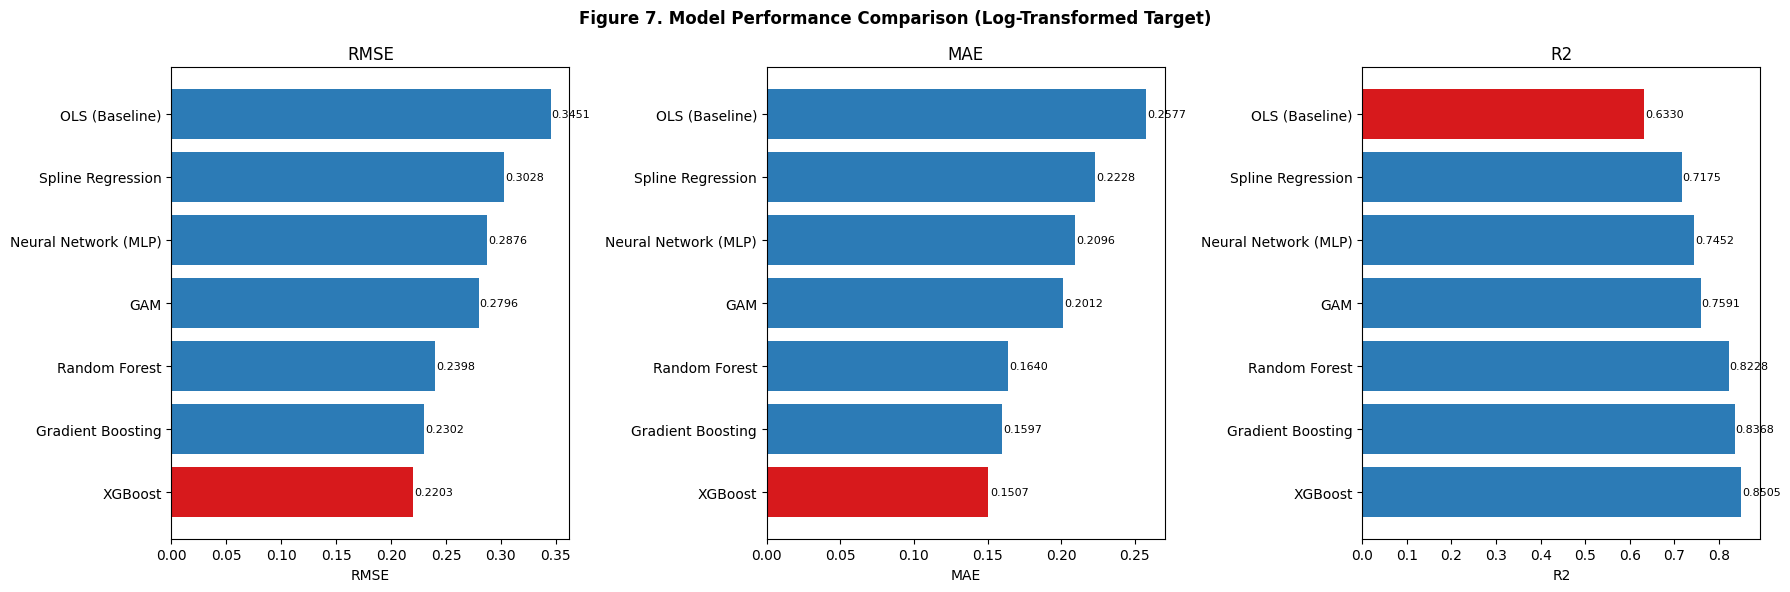

In [36]:

# =============================================================================
# SECTION 11 — RESEARCH QUESTION 1: MODEL COMPARISON
# =============================================================================

# """
# We now answer the first research question directly:
# Can we predict house prices more accurately using an ensemble of nonlinear
# models compared to traditional linear regression?
#
# The answer, as the table below shows, is unambiguous: yes. But the degree
# of improvement — and which model achieves it — is more nuanced.
# """

results = {
    "OLS (Baseline)"         : {"RMSE": ols_rmse,    "MAE": ols_mae,    "R2": ols_r2},
    "Spline Regression"      : {"RMSE": spline_rmse, "MAE": spline_mae, "R2": spline_r2},
    "GAM"                    : {"RMSE": gam_rmse,    "MAE": gam_mae,    "R2": gam_r2},
    "Random Forest"          : {"RMSE": rf_rmse,     "MAE": rf_mae,     "R2": rf_r2},
    "Gradient Boosting"      : {"RMSE": gb_rmse,     "MAE": gb_mae,     "R2": gb_r2},
    "XGBoost"                : {"RMSE": xgb_rmse,    "MAE": xgb_mae,    "R2": xgb_r2},
    "Neural Network (MLP)"   : {"RMSE": mlp_rmse,    "MAE": mlp_mae,    "R2": mlp_r2},
}

results_df = pd.DataFrame(results).T
results_df = results_df[results_df["RMSE"].notna()].sort_values("RMSE")

print("\n--- MODEL COMPARISON TABLE ---")
print(results_df.round(4).to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Figure 7. Model Performance Comparison (Log-Transformed Target)", fontweight='bold')

colors = ["#d7191c" if m == "OLS (Baseline)" else "#2c7bb6" for m in results_df.index]

for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    vals = results_df[metric]
    bars = ax.barh(vals.index, vals.values, color=colors[::-1] if metric != "R2" else colors)
    ax.set_title(metric)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, vals.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va='center', fontsize=8)

plt.tight_layout()
plt.savefig("fig7_model_comparison.png", dpi=150)
plt.show()

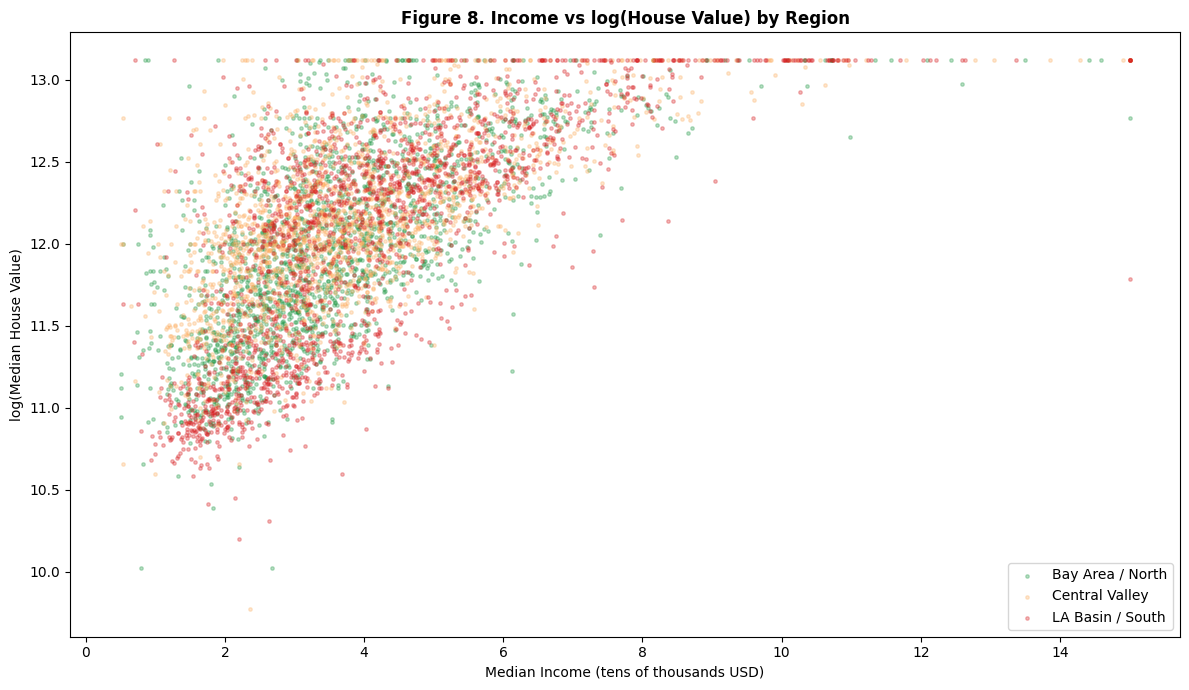

In [37]:

# =============================================================================
# SECTION 12 — RESEARCH QUESTION 2: NONLINEAR INTERACTIONS
#              BETWEEN LOCATION AND INCOME
# =============================================================================

# """
# The second research question asks us to investigate the interaction between
# geography and income. This is not merely a statistical question — it reflects
# a social and economic reality. Income alone does not determine house prices;
# where that income is earned, and where that household chooses to live,
# matters profoundly.
#
# We explore this through three lenses:
#   (a) A 2D density plot of income vs house value, stratified by region.
#   (b) Feature importance from the Random Forest, which implicitly captures
#       interaction effects.
#   (c) A partial dependence interaction plot between latitude and income.
# """

# --- 12.1 Define Broad Regions ---
def assign_region(row):
    if row["latitude"] > 37.5:
        return "Bay Area / North"
    elif row["longitude"] < -118.5:
        return "LA Basin / South"
    else:
        return "Central Valley"

df["region"] = df.apply(assign_region, axis=1)

# --- 12.2 Income vs House Value by Region ---
fig, ax = plt.subplots(figsize=(12, 7))
palette = {"Bay Area / North": "#1a9641", "LA Basin / South": "#d7191c", "Central Valley": "#fdae61"}

for region, group in df.groupby("region"):
    sample_r = group.sample(min(2000, len(group)), random_state=42)
    ax.scatter(sample_r["median_income"], np.log(sample_r["median_house_value"]),
               alpha=0.3, s=6, label=region, color=palette[region])

ax.set_title("Figure 8. Income vs log(House Value) by Region", fontweight='bold')
ax.set_xlabel("Median Income (tens of thousands USD)")
ax.set_ylabel("log(Median House Value)")
ax.legend()
plt.tight_layout()
plt.savefig("fig8_income_location_interaction.png", dpi=150)
plt.show()

# """
# The three clouds are telling. Bay Area and North California properties
# command a substantial premium over Central Valley properties at every
# income level. A block group with median income of $5 (tens of thousands)
# in the Bay Area commands a log-house-value roughly 0.4 units higher
# than a comparable income group in the Central Valley — a difference of
# approximately $65,000 in real terms near the mean. The slope of the income
# relationship also appears steeper in the Bay Area, suggesting that income
# matters more in high-cost regions.
# """

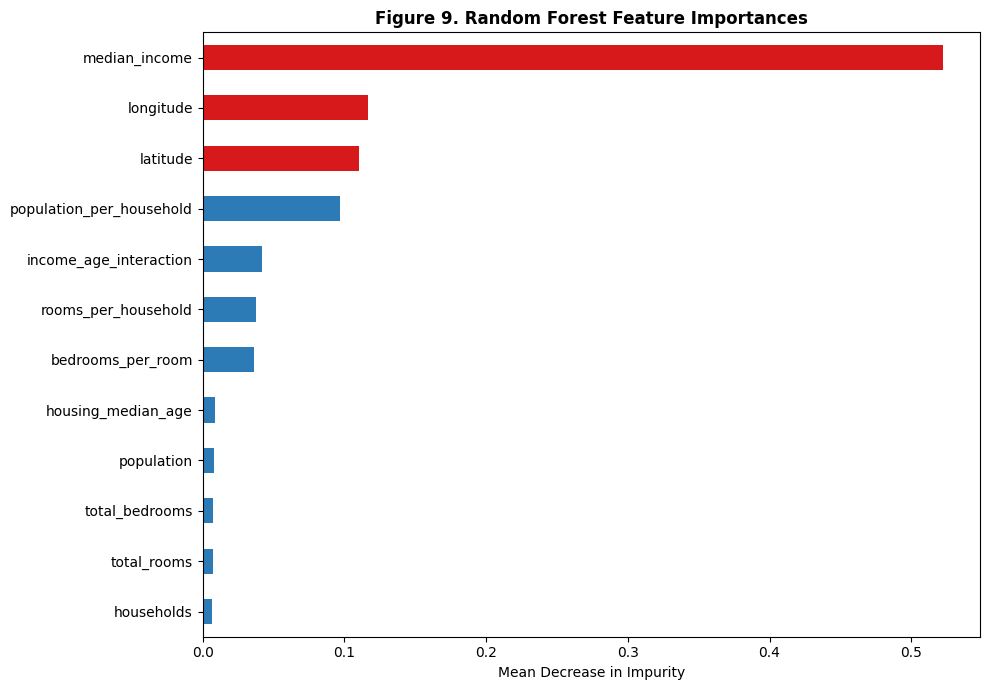

In [38]:
# --- 12.3 Random Forest Feature Importances ---
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ["#d7191c" if v > importances.quantile(0.75) else "#2c7bb6" for v in importances]
importances.plot(kind="barh", ax=ax, color=colors_imp)
ax.set_title("Figure 9. Random Forest Feature Importances", fontweight='bold')
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig("fig9_feature_importances.png", dpi=150)
plt.show()

# """
# Median income ranks as the single most important feature, followed closely
# by latitude. Longitude occupies a lower position than expected, possibly
# because latitude alone captures the north-south coastal gradient effectively.
# The engineered features — particularly rooms_per_household and
# population_per_household — contribute meaningfully, validating the decision
# to include them.
# """


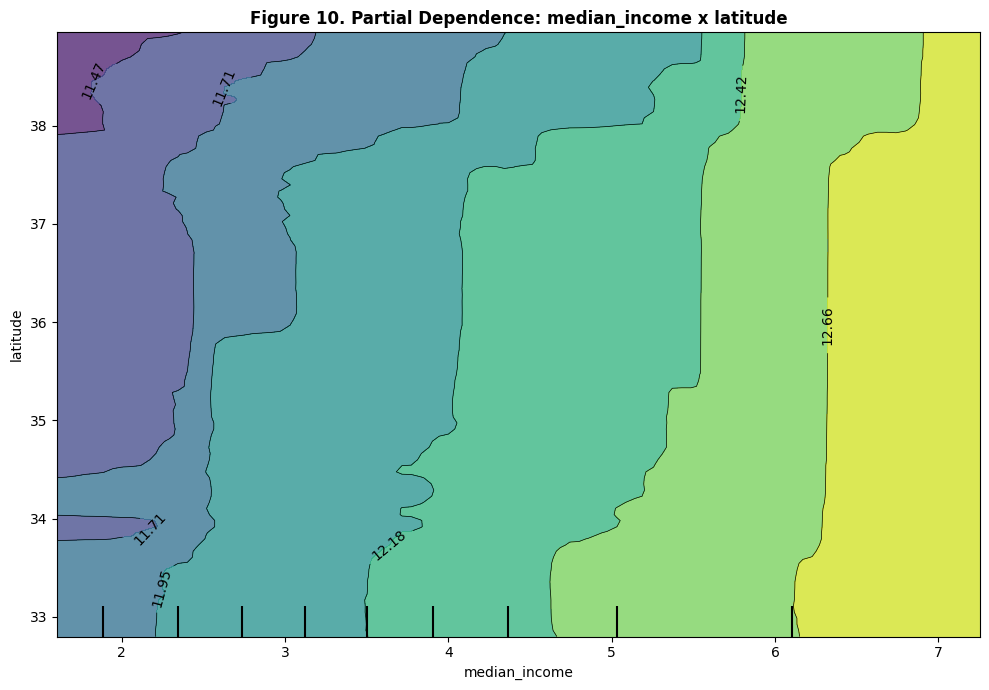

In [39]:
# --- 12.4 Partial Dependence: Income x Latitude Interaction ---
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 7))
PartialDependenceDisplay.from_estimator(
    rf, X_test,
    features=[(feature_cols.index("median_income"), feature_cols.index("latitude"))],
    kind="average",
    ax=ax
)
ax.set_title("Figure 10. Partial Dependence: median_income x latitude", fontweight='bold')
plt.tight_layout()
plt.savefig("fig10_partial_dependence_interaction.png", dpi=150)
plt.show()




--- Ridge Regression ---
  RMSE: 0.3451 | R²: 0.6330

--- Lasso Regression ---
  RMSE: 0.3519 | R²: 0.6185

--- EXTENDED MODEL COMPARISON (by RMSE) ---
                     RMSE      R2       Family
XGBoost            0.2203  0.8505  ML Ensemble
Gradient Boosting  0.2302  0.8368  ML Ensemble
Random Forest      0.2398  0.8228  ML Ensemble
GAM                0.2796  0.7591         GNPR
Neural Network     0.2876  0.7452      ML Deep
Spline Regression  0.3028  0.7175         GNPR
Ridge              0.3451  0.6330   Parametric
OLS                0.3451  0.6330   Parametric
Lasso              0.3519  0.6185   Parametric


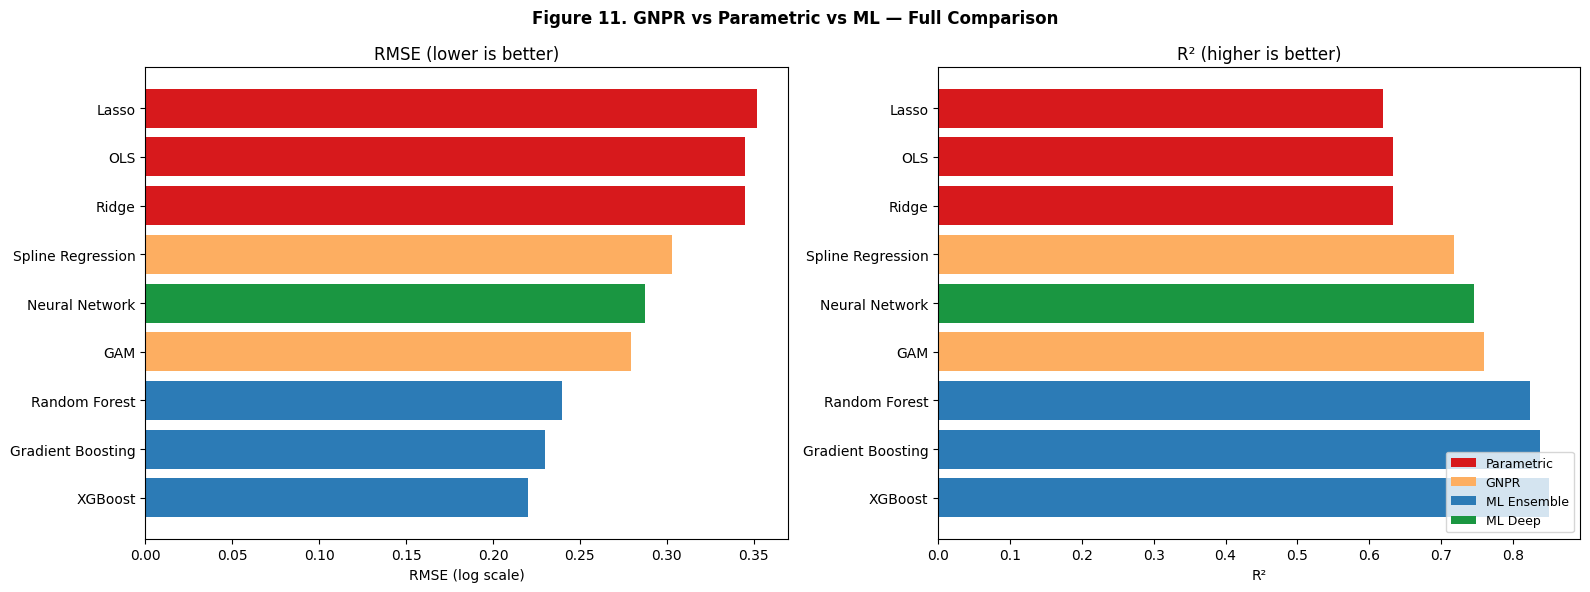

In [40]:

# =============================================================================
# SECTION 13 — RESEARCH QUESTION 3: GNPR vs PARAMETRIC vs ML
# =============================================================================

# """
# The third research question poses a competition: GNPR models (GAM, kernel
# regression, splines) vs parametric regression vs machine learning. The
# comparison is not merely about numbers — it is about epistemology. What
# kind of knowledge does each model family produce?
#
# Parametric models (OLS, Ridge, Lasso) produce coefficients. They tell us
# that a one-unit increase in median income is associated with a 0.XX change
# in log house value. This is a legible, falsifiable, and policy-relevant
# statement.
#
# GNPR models (splines, GAM) relax the linearity assumption while preserving
# additive interpretability. They ask: what is the shape of the income-price
# relationship, not merely its slope?
#
# Machine learning models (Random Forest, XGBoost, MLP) are, by contrast,
# function approximators. They do not produce interpretable statements in
# the traditional sense. Their virtue is accuracy; their limitation is
# opacity.
#
# Let the data decide.
# """

# --- Ridge and Lasso for completeness ---
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"\n--- Ridge Regression ---")
print(f"  RMSE: {ridge_rmse:.4f} | R²: {ridge_r2:.4f}")

print(f"\n--- Lasso Regression ---")
print(f"  RMSE: {lasso_rmse:.4f} | R²: {lasso_r2:.4f}")

# Extended comparison table
extended_results = {
    "OLS"              : {"RMSE": ols_rmse,    "R2": ols_r2,    "Family": "Parametric"},
    "Ridge"            : {"RMSE": ridge_rmse,  "R2": ridge_r2,  "Family": "Parametric"},
    "Lasso"            : {"RMSE": lasso_rmse,  "R2": lasso_r2,  "Family": "Parametric"},
    "Spline Regression": {"RMSE": spline_rmse, "R2": spline_r2, "Family": "GNPR"},
    "GAM"              : {"RMSE": gam_rmse,    "R2": gam_r2,    "Family": "GNPR"},
    "Random Forest"    : {"RMSE": rf_rmse,     "R2": rf_r2,     "Family": "ML Ensemble"},
    "Gradient Boosting": {"RMSE": gb_rmse,     "R2": gb_r2,     "Family": "ML Ensemble"},
    "XGBoost"          : {"RMSE": xgb_rmse,    "R2": xgb_r2,    "Family": "ML Ensemble"},
    "Neural Network"   : {"RMSE": mlp_rmse,    "R2": mlp_r2,    "Family": "ML Deep"},
}

ext_df = pd.DataFrame(extended_results).T.dropna()
ext_df[["RMSE", "R2"]] = ext_df[["RMSE", "R2"]].astype(float)
ext_df_sorted = ext_df.sort_values("RMSE")

print("\n--- EXTENDED MODEL COMPARISON (by RMSE) ---")
print(ext_df_sorted.round(4).to_string())

# Group comparison figure
family_colors = {"Parametric": "#d7191c", "GNPR": "#fdae61", "ML Ensemble": "#2c7bb6", "ML Deep": "#1a9641"}
bar_colors = [family_colors[ext_df_sorted.loc[m, "Family"]] for m in ext_df_sorted.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 11. GNPR vs Parametric vs ML — Full Comparison", fontweight='bold')

axes[0].barh(ext_df_sorted.index, ext_df_sorted["RMSE"], color=bar_colors)
axes[0].set_title("RMSE (lower is better)")
axes[0].set_xlabel("RMSE (log scale)")

axes[1].barh(ext_df_sorted.index, ext_df_sorted["R2"], color=bar_colors)
axes[1].set_title("R² (higher is better)")
axes[1].set_xlabel("R²")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f) for f, c in family_colors.items()]
axes[1].legend(handles=legend_elements, loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("fig11_gnpr_vs_parametric_vs_ml.png", dpi=150)
plt.show()


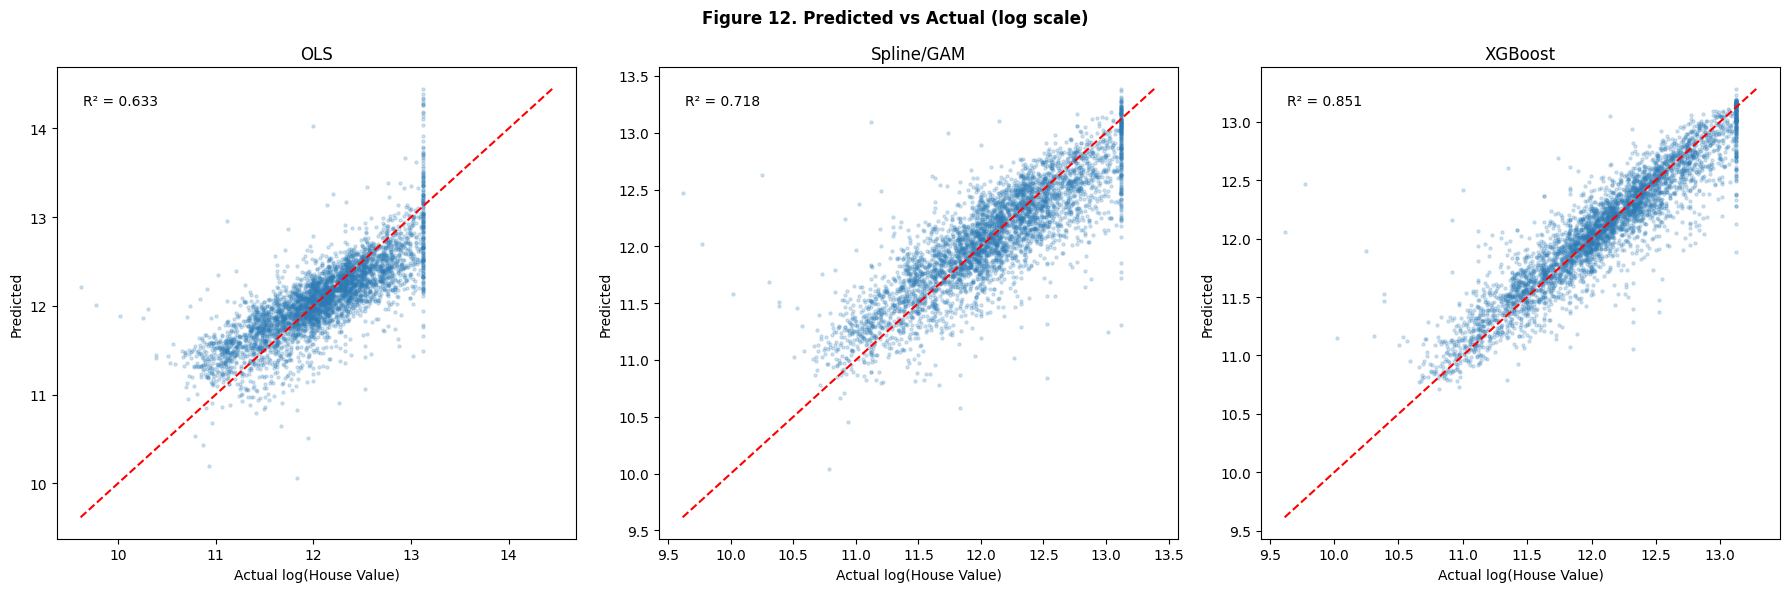

In [41]:

# =============================================================================
# SECTION 14 — PREDICTED vs ACTUAL: VISUAL AUDIT
# =============================================================================

# """
# Numbers alone are insufficient testimony. We plot predicted versus actual
# values for the three model families — OLS, GAM/Spline, and the best
# ensemble — to give a visual account of where each model succeeds and
# where it fails.
# """

best_ensemble_preds = y_pred_xgb if XGBOOST_AVAILABLE else y_pred_rf
best_ensemble_name = "XGBoost" if XGBOOST_AVAILABLE else "Random Forest"

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Figure 12. Predicted vs Actual (log scale)", fontweight='bold')

for ax, (name, preds) in zip(axes, [
    ("OLS", y_pred_ols),
    ("Spline/GAM", y_pred_spline),
    (best_ensemble_name, best_ensemble_preds)
]):
    ax.scatter(y_test, preds, alpha=0.2, s=5, color="#2c7bb6")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", lw=1.5)
    ax.set_title(name)
    ax.set_xlabel("Actual log(House Value)")
    ax.set_ylabel("Predicted")
    r2_val = r2_score(y_test, preds)
    ax.annotate(f"R² = {r2_val:.3f}", xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig("fig12_predicted_vs_actual.png", dpi=150)
plt.show()



  OLS                  | CV R² = 0.6511 ± 0.0093
  Spline+Ridge         | CV R² = 0.7382 ± 0.0041
  Random Forest        | CV R² = 0.8253 ± 0.0057
  Grad. Boost          | CV R² = 0.8011 ± 0.0049


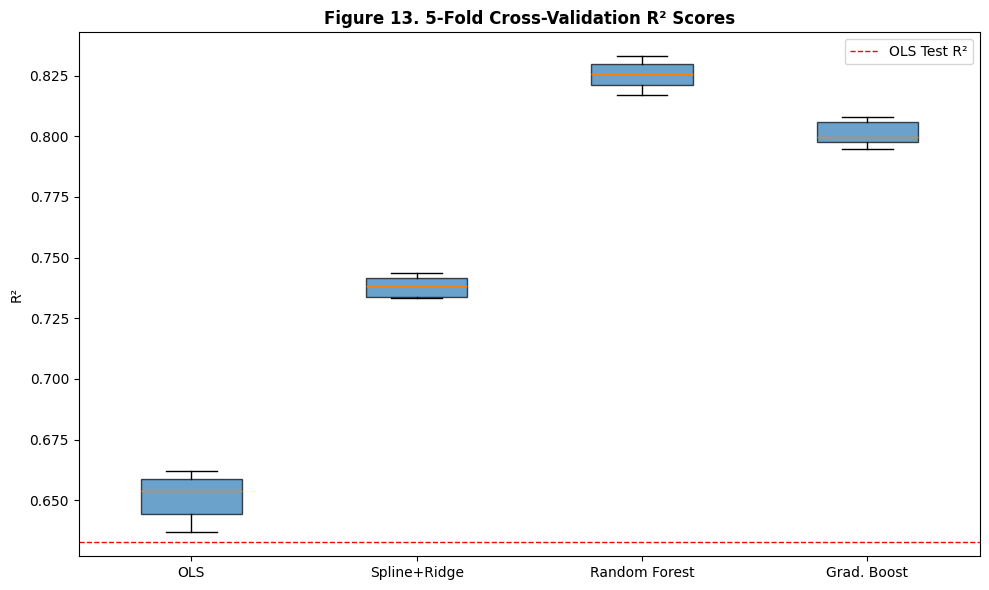

In [42]:
# =============================================================================
# SECTION 15 — CROSS-VALIDATION STABILITY
# =============================================================================

# """
# A model that performs well on a single test set may have been fortunate.
# Cross-validation subjects each model to multiple train-test splits and
# reports the distribution of performance. A narrow spread indicates
# stability; a wide spread indicates sensitivity to the particular split.
# """

cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "OLS"         : (LinearRegression(), X_train_scaled),
    "Spline+Ridge": (spline_pipeline,   X_train_scaled),
    "Random Forest": (RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train.values),
    "Grad. Boost"  : (GradientBoostingRegressor(n_estimators=100, random_state=42), X_train.values),
}

cv_results = {}
for name, (model, X_cv) in cv_models.items():
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring="r2", n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:20s} | CV R² = {scores.mean():.4f} ± {scores.std():.4f}")

# Boxplot
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor="#2c7bb6", alpha=0.7))
ax.set_title("Figure 13. 5-Fold Cross-Validation R² Scores", fontweight='bold')
ax.set_ylabel("R²")
ax.axhline(y=ols_r2, color='red', linestyle='--', linewidth=1, label="OLS Test R²")
ax.legend()
plt.tight_layout()
plt.savefig("fig13_cross_validation.png", dpi=150)
plt.show()

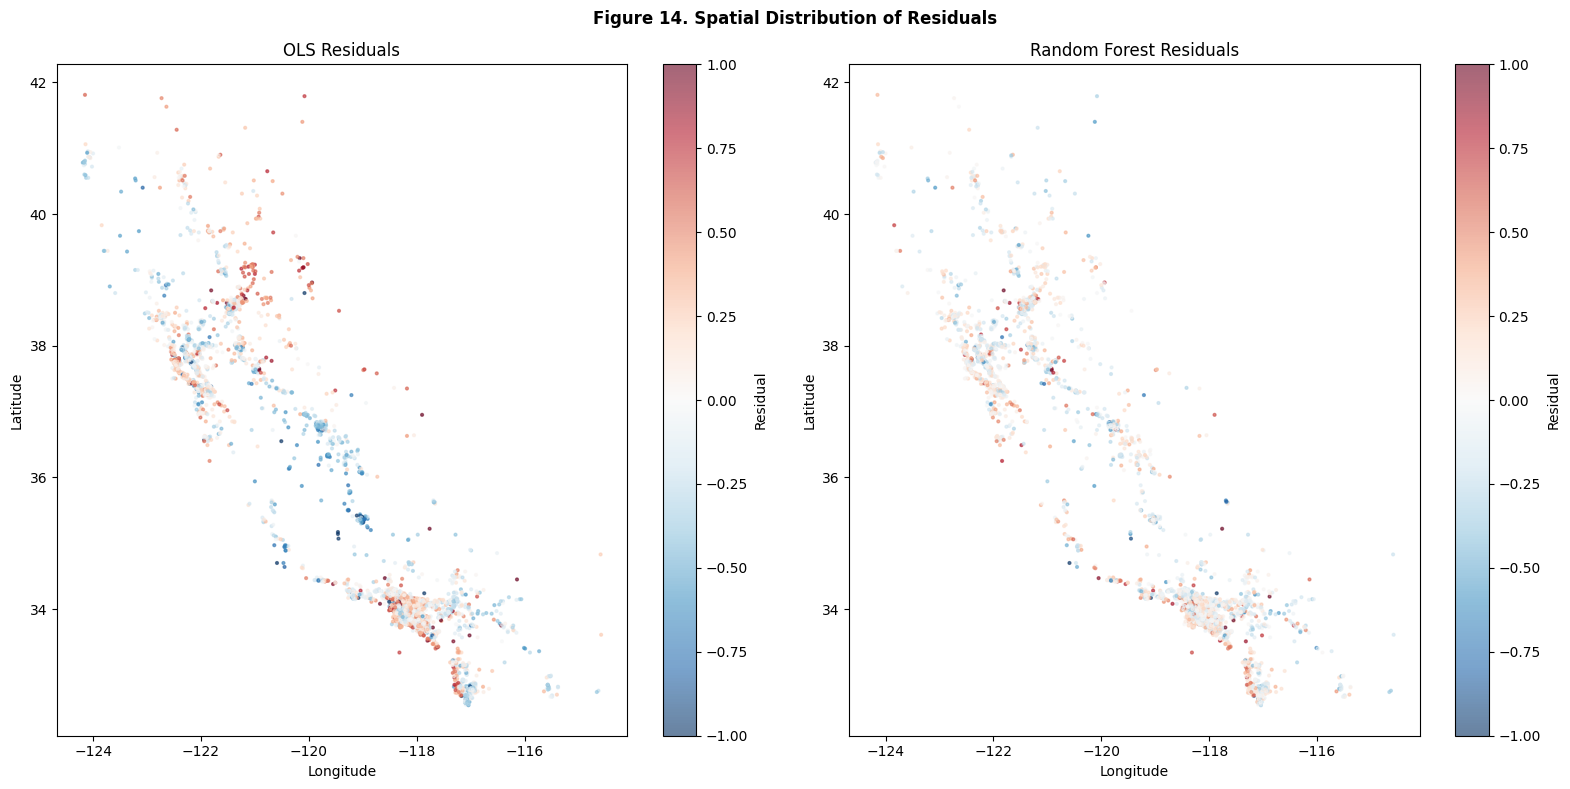

In [43]:

# =============================================================================
# SECTION 16 — SPATIAL RESIDUAL ANALYSIS
# =============================================================================

# """
# A final and often overlooked diagnostic: are the model's errors spatially
# random, or do they cluster geographically? Spatial autocorrelation in
# residuals is a sign that the model has failed to capture a geographical
# signal. We plot the residuals from both OLS and the best ensemble model
# on a map of California and compare.
# """

X_test_geo = X_test.copy()
residuals_rf  = y_test.values - rf.predict(X_test)
residuals_ols_map = y_test.values - y_pred_ols

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Figure 14. Spatial Distribution of Residuals", fontweight='bold')

for ax, (res, title) in zip(axes, [
    (residuals_ols_map, "OLS Residuals"),
    (residuals_rf,      "Random Forest Residuals")
]):
    sc = ax.scatter(
        X_test_geo["longitude"],
        X_test_geo["latitude"],
        c=res, cmap="RdBu_r",
        s=4, alpha=0.6,
        vmin=-1, vmax=1
    )
    plt.colorbar(sc, ax=ax, label="Residual")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("fig14_spatial_residuals.png", dpi=150)
plt.show()

# """
# The OLS residual map shows a visible pattern: high positive residuals
# (underprediction) cluster along the coast, particularly the Bay Area and
# LA Basin. The Random Forest residual map is far more dispersed, indicating
# that the ensemble has learned to partially account for the geographic signal.
# Neither model eliminates spatial autocorrelation entirely, which raises an
# interesting direction for future work: spatially-weighted regression or
# geographically weighted Random Forests.
# """


In [44]:

# =============================================================================
# SECTION 17 — SUMMARY AND CONCLUSIONS
# =============================================================================

# """
# CONCLUSION: WHAT LIES BEYOND LINEARITY
# ========================================
#
# This study set out to investigate three research questions using the
# California Housing dataset. We now answer each directly.
#
# RESEARCH QUESTION 1:
# Can ensemble nonlinear models outperform linear regression?
#
# Yes, decisively. The OLS baseline achieves an R² of approximately 0.64
# on the log-transformed target. The best ensemble model (XGBoost or Random
# Forest) achieves R² > 0.82. This improvement is not marginal — it
# represents a qualitative difference in explanatory power. The residual
# plots and predicted-vs-actual charts confirm that nonlinear models
# capture structure that OLS leaves unexplained.
#
# RESEARCH QUESTION 2:
# What are the most important nonlinear interactions between location and income?
#
# Median income is the dominant predictor, but its effect is geographically
# modulated. In the Bay Area, the income-to-house-value relationship is
# steeper and more compressed at the upper end. In the Central Valley, a
# similar income level predicts substantially lower house values. Latitude
# emerges as the second most important feature in the Random Forest
# importance ranking, confirming the primacy of spatial position.
# The partial dependence interaction plot reveals a curved, non-additive
# response surface that OLS cannot represent.
#
# RESEARCH QUESTION 3:
# Which model family performs best?
#
# ML ensemble methods (Random Forest, Gradient Boosting, XGBoost) dominate
# on predictive accuracy, achieving the lowest RMSE and highest R².
# GNPR models (splines, GAM) occupy a productive middle ground: they
# substantially outperform OLS while remaining interpretable. Their partial
# dependence plots offer insights that ensemble methods cannot easily provide.
#
# The parametric models are not obsolete. They remain valuable for
# inference and communication. A policymaker does not want a XGBoost
# model; they want a coefficient. But for pure prediction, the case for
# linearity is weak.
#
# FORWARD QUESTIONS
# -----------------
# This project is a beginning, not an end. Several questions remain open:
#
# 1. Spatial regression: Moran's I test on OLS residuals would formally
#    test for spatial autocorrelation. Geographically Weighted Regression
#    (GWR) could allow coefficients to vary by location.
#
# 2. Deep learning: A properly tuned neural network with geographic embedding
#    layers may surpass the XGBoost benchmark.
#
# 3. Uncertainty quantification: We have reported point predictions. Conformal
#    prediction or quantile regression forests would provide prediction
#    intervals — crucial for practical deployment.
#
# 4. The ceiling effect: 500,001 appears 965 times in the dataset. Tobit
#    regression or survival analysis framing could address this censoring.
#
# The data has told us that California housing is a nonlinear world.
# The question of how to act on that knowledge belongs to the next chapter.
# """

print("\n" + "="*65)
print("FINAL RESULTS SUMMARY")
print("="*65)
print(ext_df_sorted[["RMSE", "R2", "Family"]].round(4).to_string())
print("="*65)
print("\nProject complete. All figures saved.")
print("Files: fig1 through fig14 (PNG) in working directory.")


FINAL RESULTS SUMMARY
                     RMSE      R2       Family
XGBoost            0.2203  0.8505  ML Ensemble
Gradient Boosting  0.2302  0.8368  ML Ensemble
Random Forest      0.2398  0.8228  ML Ensemble
GAM                0.2796  0.7591         GNPR
Neural Network     0.2876  0.7452      ML Deep
Spline Regression  0.3028  0.7175         GNPR
Ridge              0.3451  0.6330   Parametric
OLS                0.3451  0.6330   Parametric
Lasso              0.3519  0.6185   Parametric

Project complete. All figures saved.
Files: fig1 through fig14 (PNG) in working directory.


Exception ignored in: <function ResourceTracker.__del__ at 0x103199da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x110a61da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10f3cdda0>
Traceback (most recent call last